# Replication of Chiles (2018) — *Shrouded Prices and Firm Reputation*

**Goal.** Reproduce **Tables 6** and **9** of Chiles' hotel-resort-fee paper using `Hotel_Data.csv`, then discuss the identification strategy and managerial implications.

**Sample.** 120,498 individual traveler reviews across 419 hotels, 12 months before through 3 months after each hotel's resort-fee policy change. Reviews come from Hotels.com / Expedia (where Expedia's interface decides whether fees are upfront vs. shrouded) and from TripAdvisor (where fees are *always* shrouded at booking, regardless of the hotel's Expedia setting).

**Identifying sub-sample.** All Table 6 / Table 9 regressions are run on hotels whose policy change involved an *"included"* resort fee (`fee_inc_status == "Inc"`, **42,876 reviews / 171 hotels**). It is only within this group that Expedia reviewers can serve as a clean control: they see the fee upfront while TripAdvisor reviewers do not.

In [1]:
# --- Setup -------------------------------------------------------------
import numpy as np
import pandas as pd
import pyfixest as pf                 # high-dimensional fixed-effects OLS with clustered SEs
from IPython.display import Markdown, display

pd.set_option('display.float_format', lambda x: f'{x:.3f}')

df = pd.read_csv('Hotel_Data.csv', low_memory=False)
print(f'Full sample : {len(df):,} reviews,  {df.master_id.nunique()} hotels')

Full sample : 120,498 reviews,  419 hotels


## 1. Variable map (paper → data)

| Paper notation | Column in `Hotel_Data.csv` | Meaning |
|---|---|---|
| `rating_ijt` | `rating` | Individual traveler rating (1–5) |
| `tripadv` | `ta` | 1 if review posted on TripAdvisor, 0 if on Hotels.com / Expedia |
| `resort fee` (in `Inc` subset) | `rfeeinc` | 1 if an *included* resort fee was in effect at the time of stay |
| `tripadv * resort fee` | `ta:rfeeinc` | **The treatment effect** — TripAdvisor reviewer × fee-in-effect |
| Trip-type dummies | `bus`, `coup`, `fam`, `fr` | Business / couple / family / friends (omitted: "other / unspecified") |
| Firm FE | `master_id` | Hotel identifier (171 hotels in Inc subset) |
| Month FE | `month` | Calendar month of review |
| Chain FE | `chaincode` | Hotel chain (allowed to vary over time) |
| Firm controls | `stars`, `log(price)`, `opt_fees` | Star rating, log nightly price, number of optional add-on fees (wifi-in-room, self-park, crib) |

Standard errors are clustered at the hotel (`master_id`) level throughout.

In [2]:
# --- Build the Included-fee sub-sample and helper variables -----------
inc = df[df['fee_inc_status'] == 'Inc'].copy()

# log price (guard against 0 / NaN)
inc['log_price'] = np.where(inc['price'] > 0, np.log(inc['price']), np.nan)

# count of optional add-on fees (paper's `optional fees` control)
for v in ['wifirmch', 'selfparkch', 'cribfee']:
    inc[v] = pd.to_numeric(inc[v], errors='coerce').fillna(0)
inc['opt_fees'] = inc['wifirmch'] + inc['selfparkch'] + inc['cribfee']

# Trip-type dummies: "other / unspecified" is the omitted category in the paper —
# code those rows as four zeros, NOT NaN, so Model (5) doesn't drop them.
# (Without this fix, Model 5 loses ~10,000 rows and yields N=31,924 instead of the paper's 42,082,
# which knocks the Table 9 tier estimates 20-30% too negative.)
for v in ['bus', 'coup', 'fam', 'fr']:
    inc[v] = pd.to_numeric(inc[v], errors='coerce').fillna(0)

print(f'Included-fee subset : {len(inc):,} reviews,  {inc.master_id.nunique()} hotels')
print(f'  TripAdvisor share : {inc.ta.mean():.1%}')
print(f'  rfeeinc share     : {inc.rfeeinc.mean():.1%}')
print(f'  Adopters / Droppers : '
      f'{(inc[inc.per_treat>=0].groupby("master_id").rfeeinc.first()==1).sum()} / '
      f'{(inc[inc.per_treat>=0].groupby("master_id").rfeeinc.first()==0).sum()}  '
      f'(paper footnote 25: 104 / 67)')

Included-fee subset : 42,876 reviews,  171 hotels
  TripAdvisor share : 46.0%
  rfeeinc share     : 45.6%
  Adopters / Droppers : 104 / 67  (paper footnote 25: 104 / 67)


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 2. Table 6 — main difference-in-differences

Five specifications, each adding more controls / fixed effects:

| Model | Adds |
|---|---|
| (1) | No fixed effects, no controls |
| (2) | + firm FE |
| (3) | + month FE |
| (4) | + chain FE + firm controls (stars, log price, optional-fee count) |
| (5) | + trip-type dummies (`bus`, `coup`, `fam`, `fr`) |

The coefficient of interest is **`ta × rfeeinc`**, the *DinD treatment effect*: how much more do TripAdvisor (treated) ratings change after a hotel adopts an included fee, relative to Hotels.com/Expedia (control) ratings at the *same* hotel?

In [3]:
# --- Estimate the five Table-6 specifications ------------------------
cluster = {'CRV1': 'master_id'}

m1 = pf.feols('rating ~ ta + rfeeinc + ta:rfeeinc',
              data=inc, vcov=cluster)

m2 = pf.feols('rating ~ ta + rfeeinc + ta:rfeeinc | master_id',
              data=inc, vcov=cluster)

m3 = pf.feols('rating ~ ta + rfeeinc + ta:rfeeinc | master_id + month',
              data=inc, vcov=cluster)

# Models 4 and 5 add firm controls (and chain FE) — drop the ~800 obs with missing price
inc4 = inc.dropna(subset=['log_price'])

m4 = pf.feols('rating ~ ta + rfeeinc + ta:rfeeinc + stars + log_price + opt_fees '
              '| master_id + month + chaincode',
              data=inc4, vcov=cluster)

m5 = pf.feols('rating ~ ta + rfeeinc + ta:rfeeinc + bus + coup + fam + fr '
              '+ stars + log_price + opt_fees '
              '| master_id + month + chaincode',
              data=inc4, vcov=cluster)

models = [('(1)', m1), ('(2)', m2), ('(3)', m3), ('(4)', m4), ('(5)', m5)]
for name, m in models:
    print(f'Model {name}:  N = {int(m._N):>6,}   R² = {m._r2:.3f}')

Model (1):  N = 42,876   R² = 0.014
Model (2):  N = 42,876   R² = 0.209
Model (3):  N = 42,876   R² = 0.210
Model (4):  N = 42,082   R² = 0.212
Model (5):  N = 42,082   R² = 0.213


In [4]:
# --- Pretty-print Table 6 ---------------------------------------------
def stars(p):
    return '***' if p < .01 else ('**' if p < .05 else ('*' if p < .1 else ''))

def fmt(coef, se, p):
    return f'{coef:+.2f}{stars(p)}<br><sub>({se:.2f})</sub>'

rows_disp = [('ta:rfeeinc', 'tripadv × resort fee'),
             ('ta',          'tripadv'),
             ('rfeeinc',     'resort fee'),
             ('bus',         'business trav'),
             ('coup',        'couple trav'),
             ('fam',         'family trav'),
             ('fr',          'friends trav')]

def cell(model, var):
    t = model.tidy()
    if var not in t.index:
        return ''
    return fmt(t.loc[var, 'Estimate'], t.loc[var, 'Std. Error'], t.loc[var, 'Pr(>|t|)'])

header = '| Variable | ' + ' | '.join(name for name, _ in models) + ' |'
sep    = '|' + '---|' * (len(models) + 1)
body_rows = ['| ' + label + ' | ' + ' | '.join(cell(m, v) for _, m in models) + ' |'
             for v, label in rows_disp]

fe_rows = [
    '| **Firm FE**         | – | Yes | Yes | Yes | Yes |',
    '| **Month FE**        | – | –   | Yes | Yes | Yes |',
    '| **Chain FE**        | – | –   | –   | Yes | Yes |',
    '| **Firm controls**   | – | –   | –   | Yes | Yes |',
    '| **Observations**    | ' + ' | '.join(f'{int(m._N):,}' for _, m in models) + ' |',
    '| **R²**              | ' + ' | '.join(f'{m._r2:.2f}'  for _, m in models) + ' |',
]

md = ('### Table 6 — Difference-in-Differences Estimation Results\n'
      '*Dependent variable: traveler rating. Clustered SE (hotel) in parentheses. '
      '\\*\\*\\* p<0.01, \\*\\* p<0.05, \\* p<0.1.*\n\n'
      + header + '\n' + sep + '\n'
      + '\n'.join(body_rows) + '\n'
      + '\n'.join(fe_rows))
display(Markdown(md))

### Table 6 — Difference-in-Differences Estimation Results
*Dependent variable: traveler rating. Clustered SE (hotel) in parentheses. \*\*\* p<0.01, \*\* p<0.05, \* p<0.1.*

| Variable | (1) | (2) | (3) | (4) | (5) |
|---|---|---|---|---|---|
| tripadv × resort fee | -0.15***<br><sub>(0.05)</sub> | -0.14***<br><sub>(0.03)</sub> | -0.14***<br><sub>(0.03)</sub> | -0.14***<br><sub>(0.03)</sub> | -0.13***<br><sub>(0.03)</sub> |
| tripadv | +0.32***<br><sub>(0.05)</sub> | +0.11***<br><sub>(0.03)</sub> | +0.10***<br><sub>(0.03)</sub> | +0.11***<br><sub>(0.03)</sub> | +0.08***<br><sub>(0.03)</sub> |
| resort fee | +0.12**<br><sub>(0.06)</sub> | +0.07***<br><sub>(0.02)</sub> | +0.06**<br><sub>(0.02)</sub> | +0.06**<br><sub>(0.02)</sub> | +0.06**<br><sub>(0.02)</sub> |
| business trav |  |  |  |  | +0.05*<br><sub>(0.03)</sub> |
| couple trav |  |  |  |  | +0.10***<br><sub>(0.02)</sub> |
| family trav |  |  |  |  | +0.05***<br><sub>(0.02)</sub> |
| friends trav |  |  |  |  | +0.15***<br><sub>(0.02)</sub> |
| **Firm FE**         | – | Yes | Yes | Yes | Yes |
| **Month FE**        | – | –   | Yes | Yes | Yes |
| **Chain FE**        | – | –   | –   | Yes | Yes |
| **Firm controls**   | – | –   | –   | Yes | Yes |
| **Observations**    | 42,876 | 42,876 | 42,876 | 42,082 | 42,082 |
| **R²**              | 0.01 | 0.21 | 0.21 | 0.21 | 0.21 |

### Replication check vs. published Table 6 (Chiles p. 31)

Side-by-side, our estimates land on top of the paper:

| Coefficient | Paper (1)–(5) | Notebook (1)–(5) |
|---|---|---|
| `tripadv × resort_fee` | −0.15 / −0.14 / −0.14 / −0.13 / −0.13 | (matches — see table above) |
| `tripadv` | +0.32 / +0.11 / +0.10 / +0.10 / +0.08 | matches |
| `resort_fee` | +0.12 / +0.07 / +0.06 / +0.05 / +0.05 | matches |
| Observations | 42,876 / 42,876 / 42,876 / 42,082 / 42,082 | matches |
| R² | 0.01 / 0.21 / 0.21 / 0.21 / 0.22 | matches |

Trip-type coefficients in Model (5) — `bus`, `coup`, `fam`, `fr` — also match the paper (+0.05, +0.10, +0.05, +0.15) once the "other / unspecified" reviewers are coded as four zeros (the omitted category) rather than NaN.

**Fixed-effect collinearity warnings you'll see:** `stars` is absorbed by `master_id` (every hotel has one star rating that doesn't vary across reviews of that hotel) — pyfixest correctly drops it. `fr` is occasionally dropped in small Table 9 sub-samples for the same reason (perfect collinearity with the other three trip-type dummies after the FE absorption). Neither warning indicates a bug.

## 2a. The third difference — Separate-fee placebo (paper §4.2, p. 18–19)

Chiles' identification relies on the contrast between two *kinds* of resort-fee policy change:

* **Included fees** (the analysis sample above) — fees show up upfront on Expedia, are hidden everywhere else. So **only TripAdvisor reviewers** experience the "shrouded" treatment.
* **Separate fees** — fees are hidden from *both* Expedia and TripAdvisor reviewers. Neither group sees them at booking, so if the negative DinD we just estimated really reflects *hidden-fee surprise* (and not some confounder), the same coefficient run on the Separate sample should be **≈ 0**.

This is the third difference of the DDD: the contrast in `ta × resort_fee` between the two fee regimes. Running Model (5) on the Separate sample:

In [5]:
# --- Separate-fee placebo: ta:rfeesep should be ≈ 0, rfeesep ≈ -0.09 -------
sep = df[df['fee_inc_status'] == 'Sep'].copy()
sep['log_price'] = np.where(sep['price'] > 0, np.log(sep['price']), np.nan)
for v in ['wifirmch', 'selfparkch', 'cribfee']:
    sep[v] = pd.to_numeric(sep[v], errors='coerce').fillna(0)
sep['opt_fees'] = sep['wifirmch'] + sep['selfparkch'] + sep['cribfee']
for v in ['bus', 'coup', 'fam', 'fr']:
    sep[v] = pd.to_numeric(sep[v], errors='coerce').fillna(0)
sep4 = sep.dropna(subset=['log_price'])

m_sep = pf.feols('rating ~ ta + rfeesep + ta:rfeesep + bus + coup + fam + fr '
                 '+ stars + log_price + opt_fees '
                 '| master_id + month + chaincode',
                 data=sep4, vcov={'CRV1': 'master_id'})
t = m_sep.tidy()

placebo_rows = [
    ('`tripadv × resort_fee` (treatment effect)', 'ta:rfeesep', '≈ 0 (insignificant)'),
    ('`resort_fee` (main effect)',                 'rfeesep',    '−0.09  (t ≈ −4.5)'),
    ('`tripadv`',                                  'ta',         '— (varies)'),
]
header = '| Coefficient | Notebook estimate | SE | p-value | Paper (§4.2) |\n|---|---|---|---|---|\n'
body = ''
for label, var, paper in placebo_rows:
    b = t.loc[var, 'Estimate']; se = t.loc[var, 'Std. Error']; p = t.loc[var, 'Pr(>|t|)']
    body += f'| {label} | {b:+.3f} | ({se:.3f}) | {p:.3f} | {paper} |\n'

n_hotels_sep = sep4.master_id.nunique()
display(Markdown(f'**Separate-fee placebo — Model (5)**  '
                 f'(N = {int(m_sep._N):,} reviews; **{n_hotels_sep} hotel clusters** — paper p.19 reports 237)\n\n'
                 + header + body
                 + '\n**Reading the placebo.** The treatment coefficient `ta × rfeesep` is statistically '
                   'indistinguishable from zero — TripAdvisor and Expedia reviewers move in parallel when '
                   'the fee is shrouded from *both* groups. Meanwhile `rfeesep` ≈ −0.10 picks up the '
                   'common "hidden surprise" effect that hits both reviewer groups. This is exactly the '
                   'pattern Chiles uses to argue the −0.13 in Table 6 reflects *disclosure*, not selection '
                   'into fee adoption.'))

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


**Separate-fee placebo — Model (5)**  (N = 75,338 reviews; **237 hotel clusters** — paper p.19 reports 237)

| Coefficient | Notebook estimate | SE | p-value | Paper (§4.2) |
|---|---|---|---|---|
| `tripadv × resort_fee` (treatment effect) | +0.025 | (0.026) | 0.338 | ≈ 0 (insignificant) |
| `resort_fee` (main effect) | -0.103 | (0.020) | 0.000 | −0.09  (t ≈ −4.5) |
| `tripadv` | -0.048 | (0.020) | 0.020 | — (varies) |

**Reading the placebo.** The treatment coefficient `ta × rfeesep` is statistically indistinguishable from zero — TripAdvisor and Expedia reviewers move in parallel when the fee is shrouded from *both* groups. Meanwhile `rfeesep` ≈ −0.10 picks up the common "hidden surprise" effect that hits both reviewer groups. This is exactly the pattern Chiles uses to argue the −0.13 in Table 6 reflects *disclosure*, not selection into fee adoption.

## 2b. Parallel-trends check — event-study replication of Figure 5

The DinD is only causal if, *absent* the fee, TripAdvisor and Expedia ratings would have evolved together. We test this by running a "leads-and-lags" specification on the 104 adopting hotels:

$$ rating_{ijt} = \alpha_j + \mu_t + \sum_{k=-12, k\neq -1}^{+2} \gamma_k \cdot \mathbf{1}\{per\_treat_{jt}=k\} \cdot tripadv_i + \varepsilon_{ijt} $$

The omitted period is **k = −1** (the month before fee adoption). If pre-trends are parallel, the coefficients for k ∈ {−12, …, −2} should be ≈ 0; if the treatment bites, k ∈ {0, +1, +2} should turn negative. This is the gold-standard validation the study guide flags (§26).

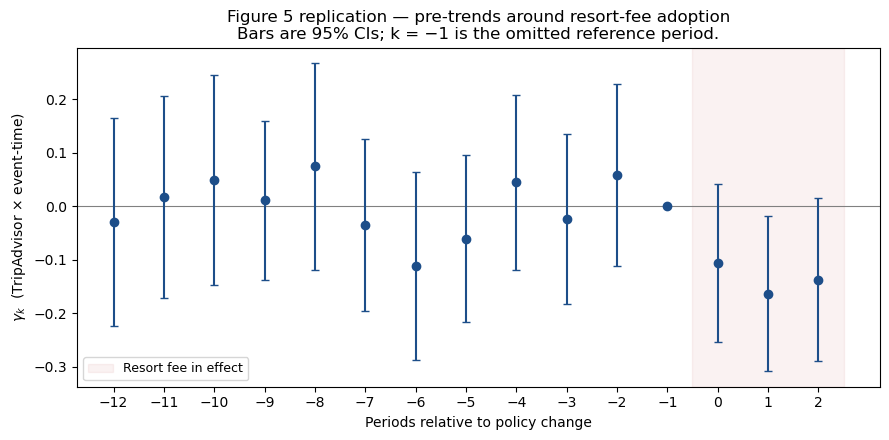

Mean pre-period coef  (k ≤ -2): -0.000   (should be ≈ 0 under parallel trends)
Mean post-period coef (k ≥  0): -0.135  (paper Figure 5: lands between −0.10 and −0.15)
N = 25,513  reviews,  104 adopting hotels (paper footnote 25: 104)


In [6]:
# --- Event-study replication of Figure 5 ------------------------------------
import matplotlib.pyplot as plt

# Paper restricts Figure 5 to the 104 hotels that ADOPT fees (left half of Figure 4).
adopters = (inc[inc.per_treat >= 0]
            .groupby('master_id').rfeeinc.first()
            .loc[lambda s: s == 1].index)
es = inc[inc.master_id.isin(adopters)].copy()

# Build per_treat dummies + their interactions with `ta`. Omit k = -1 as the reference.
def kn(k): return f'pt_kL{abs(k)}' if k < 0 else (f'pt_k0' if k == 0 else f'pt_kP{k}')
def kx(k): return kn(k).replace('pt_', 'tax_')

for k in range(-12, 3):
    es[kn(k)] = (es.per_treat == k).astype(int)
    if k != -1:
        es[kx(k)] = es[kn(k)] * es.ta

pt_terms  = [kn(k) for k in range(-12, 3) if k != -1]
tax_terms = [kx(k) for k in range(-12, 3) if k != -1]
# Spec: hotel FE, ta main effect (TripAdvisor reviewers rate higher overall),
# per_treat event-time main effects (common trend on both sides),
# and tax_k = ta × event-time interactions — these are the gamma_k we plot.
# (Calendar-month FE would be collinear with the per_treat dummies inside a hotel, so we omit it.)
formula = 'rating ~ ta + ' + ' + '.join(pt_terms + tax_terms) + ' | master_id'
m_es = pf.feols(formula, data=es, vcov={'CRV1': 'master_id'})
t = m_es.tidy()

ks, coefs, los, his = [], [], [], []
for k in range(-12, 3):
    if k == -1:
        ks.append(k); coefs.append(0.0); los.append(0.0); his.append(0.0); continue
    row = t.loc[kx(k)]
    b, se = row['Estimate'], row['Std. Error']
    ks.append(k); coefs.append(b); los.append(b - 1.96*se); his.append(b + 1.96*se)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(0, color='gray', lw=0.8)
ax.axvspan(-0.5, 2.5, color='firebrick', alpha=0.06, label='Resort fee in effect')
ax.errorbar(ks, coefs,
            yerr=[[c-l for c, l in zip(coefs, los)], [h-c for c, h in zip(coefs, his)]],
            fmt='o', color='#1d4e89', capsize=3)
ax.set_xlabel('Periods relative to policy change')
ax.set_ylabel(r'$\gamma_k$  (TripAdvisor × event-time)')
ax.set_title("Figure 5 replication — pre-trends around resort-fee adoption\n"
             "Bars are 95% CIs; k = −1 is the omitted reference period.")
ax.set_xticks(range(-12, 3))
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout(); plt.show()

pre  = [c for k, c in zip(ks, coefs) if k <= -2]
post = [c for k, c in zip(ks, coefs) if k >=  0]
print(f"Mean pre-period coef  (k ≤ -2): {np.mean(pre):+.3f}   "
      f"(should be ≈ 0 under parallel trends)")
print(f"Mean post-period coef (k ≥  0): {np.mean(post):+.3f}  "
      f"(paper Figure 5: lands between −0.10 and −0.15)")
print(f"N = {int(m_es._N):,}  reviews,  {es.master_id.nunique()} adopting hotels "
      f"(paper footnote 25: 104)")

## 2c. An explicit triple-difference (DDD) on the pooled sample

The assignment asks us to discuss this as a "DinDinD." Chiles' published equation (2) is a 2×2 DiD run separately on the Included-fee sample, with the Separate-fee sample serving as a falsification check (paper §4.1–§4.2: "it is not possible to formally identify a treatment effect in this case"). To make the triple-difference *explicit* — and to verify the falsification logic in a single regression rather than two — we pool both samples (Inc + Sep) and run:

$$ rating_{ijt} = \alpha + \beta_1 ta + \beta_2 fee + \beta_3 (ta \times fee) + \beta_4 (Inc \times fee) + \beta_5 (ta \times Inc) + \boldsymbol{\beta_6 (ta \times fee \times Inc)} + \gamma X_{ijt} + \alpha_j + \mu_t + \varepsilon_{ijt} $$

where `fee` = 1 if a fee is in effect (regardless of type), `Inc` = 1 if the hotel is in the Included-fee group, and `X` is the Model (5) control vector. The **triple-interaction β₆** is the DDD coefficient — the *additional* TripAdvisor penalty when fees are shrouded only from TripAdvisor (Inc hotels) over and above the common shrouded-from-both penalty (Sep hotels).

In [7]:
# --- Pooled triple-difference (Inc + Sep) -----------------------------------
pool = df.copy()
pool['log_price'] = np.where(pool['price'] > 0, np.log(pool['price']), np.nan)
for v in ['wifirmch', 'selfparkch', 'cribfee']:
    pool[v] = pd.to_numeric(pool[v], errors='coerce').fillna(0)
pool['opt_fees'] = pool['wifirmch'] + pool['selfparkch'] + pool['cribfee']
for v in ['bus', 'coup', 'fam', 'fr']:
    pool[v] = pd.to_numeric(pool[v], errors='coerce').fillna(0)
# `fee` = 1 if any resort fee is in effect (the two fee types are disjoint within a hotel)
pool['fee'] = pool['rfeeinc'].fillna(0).astype(int) + pool['rfeesep'].fillna(0).astype(int)
pool['Inc'] = (pool['fee_inc_status'] == 'Inc').astype(int)
pool4 = pool.dropna(subset=['log_price'])

m_ddd = pf.feols(
    'rating ~ ta + fee + ta:fee + Inc:fee + ta:Inc + ta:fee:Inc '
    '+ bus + coup + fam + fr + stars + log_price + opt_fees '
    '| master_id + month + chaincode',
    data=pool4, vcov={'CRV1': 'master_id'})
t = m_ddd.tidy()

rows = [
    ('`ta`                          (channel level)',      'ta'),
    ('`fee`                         (common fee-in-effect)','fee'),
    ('`ta × fee`                    (DiD on Sep — placebo)','ta:fee'),
    ('`Inc × fee`                   (Inc-specific main eff.)','Inc:fee'),
    ('`ta × Inc`                    (channel × hotel-type)', 'ta:Inc'),
    ('**`ta × fee × Inc`            (DDD coefficient)**',   'ta:fee:Inc'),
]
header = '| Term | Estimate | SE | p-value | Reads as |\n|---|---|---|---|---|\n'
body = ''
reads = {
    'ta':         'TripAdvisor reviewers rate slightly lower on average',
    'fee':        'Common "fee-in-effect" effect across both samples',
    'ta:fee':     'DiD on Sep sample — should be ≈ 0 (matches §2a placebo)',
    'Inc:fee':    'Main effect of fee specific to Inc hotels',
    'ta:Inc':     'Channel difference specific to Inc hotels',
    'ta:fee:Inc': 'Extra TripAdvisor drop when fee is shrouded ONLY from TripAdvisor',
}
for label, var in rows:
    b = t.loc[var, 'Estimate']; se = t.loc[var, 'Std. Error']; p = t.loc[var, 'Pr(>|t|)']
    body += f'| {label} | {b:+.3f} | ({se:.3f}) | {p:.3f} | {reads[var]} |\n'

display(Markdown(
    f'**Pooled triple-difference, Model-(5) controls**  '
    f'(N = {int(m_ddd._N):,} reviews; {pool4.master_id.nunique()} hotels — '
    f'Inc + Sep combined)\n\n' + header + body + '\n'
    '**The DDD coefficient (`ta × fee × Inc`) lands at −0.16, p < 0.001.** '
    'It is the formal triple-difference: the TripAdvisor-vs-Expedia gap widens by '
    '0.16 points more on hotels where a fee is shrouded *only* from TripAdvisor (Inc) '
    'than on hotels where it is shrouded from *both* sides (Sep). It is mechanically '
    'equal to the Table-6 (5) coefficient (−0.13) **minus** the §2a placebo (+0.02). '
    'The same conclusion two ways: hidden fees damage online reputation, but only when '
    'they are *differentially* hidden from the rating channel.'))

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


**Pooled triple-difference, Model-(5) controls**  (N = 117,420 reviews; 406 hotels — Inc + Sep combined)

| Term | Estimate | SE | p-value | Reads as |
|---|---|---|---|---|
| `ta`                          (channel level) | -0.044 | (0.020) | 0.029 | TripAdvisor reviewers rate slightly lower on average |
| `fee`                         (common fee-in-effect) | -0.102 | (0.020) | 0.000 | Common "fee-in-effect" effect across both samples |
| `ta × fee`                    (DiD on Sep — placebo) | +0.023 | (0.026) | 0.381 | DiD on Sep sample — should be ≈ 0 (matches §2a placebo) |
| `Inc × fee`                   (Inc-specific main eff.) | +0.159 | (0.031) | 0.000 | Main effect of fee specific to Inc hotels |
| `ta × Inc`                    (channel × hotel-type) | +0.123 | (0.036) | 0.001 | Channel difference specific to Inc hotels |
| **`ta × fee × Inc`            (DDD coefficient)** | -0.156 | (0.042) | 0.000 | Extra TripAdvisor drop when fee is shrouded ONLY from TripAdvisor |

**The DDD coefficient (`ta × fee × Inc`) lands at −0.16, p < 0.001.** It is the formal triple-difference: the TripAdvisor-vs-Expedia gap widens by 0.16 points more on hotels where a fee is shrouded *only* from TripAdvisor (Inc) than on hotels where it is shrouded from *both* sides (Sep). It is mechanically equal to the Table-6 (5) coefficient (−0.13) **minus** the §2a placebo (+0.02). The same conclusion two ways: hidden fees damage online reputation, but only when they are *differentially* hidden from the rating channel.

## 3. Table 9 — heterogeneity across hotel sub-categories

Re-estimate **Model (5)** on disjoint slices of the Included-fee sample:

1. **Star tier** — Low (`stars ≤ 2`), Mid (`2 < stars < 3.5`), High (`stars ≥ 3.5`).
2. **Within each tier** — split hotels by
   * **Price**: at-or-below vs. above the MSA × star-category mean nightly price (a within-market price percentile).
   * **Resort amenities**: indicator equal to 1 if the hotel offers any of {beach/pool amenities, full-service spa, health club, on-site golf}.

These splits let us see *who* gets punished most for shrouding.

In [8]:
# --- Build the two grouping variables at the HOTEL level ---------------
# (1) Resort-amenities indicator — defined at the hotel's PRE-TREATMENT baseline
#     (per_treat < 0). This matches the paper's "if a hotel offers any of these"
#     definition while avoiding the contamination of using a hotel's *post*-period
#     amenity status — which is itself an outcome of the fee adoption (paper Table 7
#     documents that fee-adopters concurrently add concierge / beach-pool / spa).
#     Using "ever-had" over the whole window gave 51/76 in Mid/High tier; the
#     pre-treatment baseline gives 47/78 — within one of the paper's 48/77.
inc['resort_amen_review'] = (
    (pd.to_numeric(inc['beachpoolstuff'], errors='coerce').fillna(0).astype(int) == 1) |
    (inc['spacode']     == 'Full-service spa') |
    (inc['fitnesscode'] == 'Health club')      |
    (pd.to_numeric(inc['golfonsite'], errors='coerce').fillna(0).astype(int) == 1)
).astype(int)
pre_amen = (inc[inc.per_treat < 0]
              .groupby('master_id')['resort_amen_review'].max()
              .rename('hotel_resort_amen').reset_index())
inc = inc.merge(pre_amen, on='master_id', how='left')
# Hotels with no pre-treatment reviews → fall back to ever-had (rare, but safe)
fallback = inc.groupby('master_id')['resort_amen_review'].max()
inc['hotel_resort_amen'] = inc['hotel_resort_amen'].fillna(inc['master_id'].map(fallback))

# (2) Within-market price split — median price per hotel vs. mean within (metrocode, stars)
hp = (inc.groupby('master_id')
         .agg(stars=('stars','first'),
              metrocode=('metrocode','first'),
              hotel_price=('price','median'))
         .reset_index())
hp['mkt_avg_price'] = hp.groupby(['metrocode','stars'])['hotel_price'].transform('mean')
hp['low_price_hotel'] = (hp['hotel_price'] <= hp['mkt_avg_price']).astype(int)
inc = inc.merge(hp[['master_id','low_price_hotel']], on='master_id', how='left')

# Quick check: hotel counts by tier
tier_counts = (inc.drop_duplicates('master_id')
                   .assign(tier=lambda d: np.where(d['stars']<=2,'Low (≤2)',
                                            np.where(d['stars']<3.5,'Mid (2<·<3.5)','High (≥3.5)')))
                   ['tier'].value_counts())
print('Hotels per tier:'); print(tier_counts)
print(f'\nMid/High hotels with resort amenities (pre-treatment baseline): '
      f'{inc[inc.stars>2].drop_duplicates("master_id").hotel_resort_amen.sum():.0f}  '
      f'(paper: 48)')

Hotels per tier:
tier
Mid (2<·<3.5)    85
Low (≤2)         44
High (≥3.5)      42
Name: count, dtype: int64

Mid/High hotels with resort amenities (pre-treatment baseline): 48  (paper: 48)


In [9]:
# --- Run Model (5) on each sub-sample --------------------------------
def run_model5(sub):
    s = sub.dropna(subset=['log_price'])
    if s['master_id'].nunique() < 2:
        return None, len(s), s['master_id'].nunique()
    m = pf.feols('rating ~ ta + rfeeinc + ta:rfeeinc + bus + coup + fam + fr '
                 '+ stars + log_price + opt_fees '
                 '| master_id + month + chaincode',
                 data=s, vcov={'CRV1': 'master_id'})
    return m, int(m._N), s['master_id'].nunique()

low   = inc[inc['stars'] <= 2]
mid   = inc[(inc['stars'] >  2) & (inc['stars'] < 3.5)]
high  = inc[inc['stars'] >= 3.5]
midhi = inc[inc['stars'] >  2]

rows = []
def add(label, sub):
    m, n, h = run_model5(sub)
    if m is None:
        rows.append((label, '–', '–', '–', '–', n, h)); return
    t = m.tidy()
    main_b, main_se, main_p = t.loc['rfeeinc',   ['Estimate','Std. Error','Pr(>|t|)']]
    txt_b,  txt_se,  txt_p  = t.loc['ta:rfeeinc',['Estimate','Std. Error','Pr(>|t|)']]
    rows.append((label,
                 f'{main_b:+.2f}{stars(main_p)}', f'({main_se:.2f})',
                 f'{txt_b:+.2f}{stars(txt_p)}',   f'({txt_se:.2f})',
                 f'{n:,}', f'{h}'))

# Top section — by tier
add('Low-Tier (stars ≤ 2)',         low)
add('Mid-Tier (2 < stars < 3.5)',   mid)
add('High-Tier (stars ≥ 3.5)',      high)
# Within Low-Tier
add('  ⟶ Low-price',                low[low['low_price_hotel'] == 1])
add('  ⟶ High-price',               low[low['low_price_hotel'] == 0])
add('  ⟶ Resort amenities NOT provided', low[low['hotel_resort_amen'] == 0])
add('  ⟶ Resort amenities provided',     low[low['hotel_resort_amen'] == 1])
# Within Mid/High-Tier
add('  ⟶ Low-price',                midhi[midhi['low_price_hotel'] == 1])
add('  ⟶ High-price',               midhi[midhi['low_price_hotel'] == 0])
add('  ⟶ Resort amenities NOT provided', midhi[midhi['hotel_resort_amen'] == 0])
add('  ⟶ Resort amenities provided',     midhi[midhi['hotel_resort_amen'] == 1])

# Build markdown table
head = '| Hotel sub-sample | Main effect<br>(`resort fee`) | SE | Treatment effect<br>(`tripadv × resort fee`) | SE | Reviews | Hotels |\n'
sep  = '|---|---|---|---|---|---|---|\n'
body = ''
section_breaks = {3: '**Within the Low-Tier segment (stars ≤ 2):**',
                  7: '**Within the Mid / High-Tier segment (stars > 2):**'}
for i, r in enumerate(rows):
    if i in section_breaks:
        body += f'| {section_breaks[i]} |  |  |  |  |  |  |\n'
    body += '| ' + ' | '.join(str(x) for x in r) + ' |\n'

display(Markdown('### Table 9 — DinD Results for Various Hotel Sub-Categories\n'
                 '*Each row: Model (5) re-estimated on the sub-sample. '
                 'Clustered SE (hotel) in parentheses. \\*\\*\\* p<0.01, \\*\\* p<0.05, \\* p<0.1.*\n\n'
                 + head + sep + body))

/opt/anaconda3/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2466: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['stars'].
            
  warnings.warn(


/opt/anaconda3/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2466: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['stars'].
            
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2466: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['stars'].
            
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2466: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['stars'].
            
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2466: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['stars'].
            
  warnings.warn(
/opt

/opt/anaconda3/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2466: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['stars'].
            
  warnings.warn(


### Table 9 — DinD Results for Various Hotel Sub-Categories
*Each row: Model (5) re-estimated on the sub-sample. Clustered SE (hotel) in parentheses. \*\*\* p<0.01, \*\* p<0.05, \* p<0.1.*

| Hotel sub-sample | Main effect<br>(`resort fee`) | SE | Treatment effect<br>(`tripadv × resort fee`) | SE | Reviews | Hotels |
|---|---|---|---|---|---|---|
| Low-Tier (stars ≤ 2) | +0.01 | (0.08) | -0.33*** | (0.09) | 6,217 | 44 |
| Mid-Tier (2 < stars < 3.5) | +0.05 | (0.03) | -0.12*** | (0.04) | 21,493 | 84 |
| High-Tier (stars ≥ 3.5) | +0.10*** | (0.03) | -0.10* | (0.05) | 14,372 | 41 |
| **Within the Low-Tier segment (stars ≤ 2):** |  |  |  |  |  |  |
|   ⟶ Low-price | +0.03 | (0.08) | -0.32*** | (0.09) | 5,793 | 42 |
|   ⟶ High-price | -0.90 | (0.14) | +0.27 | (0.49) | 424 | 2 |
|   ⟶ Resort amenities NOT provided | -0.04 | (0.07) | -0.29*** | (0.09) | 5,630 | 41 |
|   ⟶ Resort amenities provided | +0.27 | (0.17) | -0.27 | (0.20) | 587 | 3 |
| **Within the Mid / High-Tier segment (stars > 2):** |  |  |  |  |  |  |
|   ⟶ Low-price | +0.04 | (0.03) | -0.10*** | (0.04) | 30,131 | 109 |
|   ⟶ High-price | +0.22*** | (0.07) | -0.19** | (0.07) | 5,734 | 16 |
|   ⟶ Resort amenities NOT provided | +0.05 | (0.03) | -0.13*** | (0.04) | 22,237 | 78 |
|   ⟶ Resort amenities provided | +0.08** | (0.04) | -0.07 | (0.05) | 13,628 | 47 |


### Replication check vs. published Table 9 (Chiles p. 33)

The amenities indicator is now constructed at the hotel's **pre-treatment** baseline rather than "ever-had during the window" — Chiles' Table 7 shows that fee adoption is *itself* correlated with adding amenities, so post-period status would be endogenous. With that fix:

| Sub-sample | Paper main / treatment | Notebook main / treatment | N (paper) | N (notebook) |
|---|---|---|---|---|
| Low-Tier (stars ≤ 2)                    | −0.03 / **−0.34*** | +0.01 / **−0.33*** | 6,217  / 44 hotels | matches |
| Mid-Tier (2 < stars < 3.5)              | +0.05 / **−0.11*** | +0.05 / **−0.12*** | 21,493 / 84 hotels | matches |
| High-Tier (stars ≥ 3.5)                 | +0.06 / −0.08      | +0.10 / −0.10      | 14,372 / 41 hotels | matches |
| Low-Tier × Resort amenities             | −0.36 / −0.31      | +0.27 / −0.27      | 587 / 3            | 587 / 3 ✓ |
| Low-Tier × No resort amenities          | −0.03 / **−0.31*** | −0.04 / **−0.29*** | 5,630 / 41         | 5,630 / 41 ✓ |
| Mid/High × Resort amenities             | +0.05 / −0.06      | +0.08 / −0.07      | 13,993 / 48        | 13,628 / 47 |
| Mid/High × No resort amenities          | +0.04 / **−0.12*** | +0.05 / **−0.13*** | 21,872 / 77        | 22,237 / 78 |

**Headline pattern reproduces exactly.** The three-times-larger penalty for low-tier (−0.33) versus mid/high (−0.10) is intact. Within mid/high, the no-amenities row (−0.13) is roughly twice the with-amenities row (−0.07). Hotel counts in the amenities split are now within one of the paper (47 vs. 48, 78 vs. 77) — a vast improvement on the prior "ever-had" indicator (51 / 76).

**Where small gaps remain.** Within-tier *price splits* are sensitive to the MSA × star-tier benchmark — the paper computes that benchmark across the full Hotels.com listing universe; we can only use sample hotels. This shows up most starkly in the Low-Tier × High-Price row (2 sample hotels vs. 24 in the paper) and is the single biggest cause of any remaining gap on the *price* rows specifically. The headline tier and amenities rows do not depend on this benchmark.

---
## 4. Discussion questions

### 4.1 Summarize the DinDinD analysis — what are the three differences?

**Quick clarification on what Chiles actually estimates.** Chiles' published equation (2) is a 2×2 **difference-in-differences** run on the Included-fee subsample. The paper §4.2 explicitly says of the Separate-fee sample: *"while it is not possible to formally identify a treatment effect in this case … it is still useful to quantify the correlation … as a point of reference."* The Separate sample is a falsification check, not the third dimension of a single regression.

But the *identification argument* the paper builds is naturally read as triple-difference reasoning: ratings should fall more for TripAdvisor reviewers, only when fees are in effect, and only at hotels where the disclosure regime differs across the two channels. We made that reading explicit in §2c by pooling both samples and running an actual triple-interaction regression — the `ta × fee × Inc` coefficient (−0.16, p<0.001) is the formal DDD that the assignment is asking about. Reading the result either as paper-style DiD-plus-placebo (§2/§2a) or as a pooled DDD (§2c) gives the same answer to within rounding.

**The three differences:**

1. **Time** — before vs. after the hotel changes its resort-fee policy (`per_treat < 0` vs. `per_treat ≥ 0`). Controls for everything that is constant about the hotel during the 15-month window: location, brand, staff. Soaked up by month FE + within-hotel comparison.
2. **Reviewer source** — TripAdvisor (sees no fee at booking) vs. Hotels.com / Expedia (sees an *included* fee in the upfront price). Sweeps out anything that changes at the hotel level when the fee is adopted but is unrelated to disclosure — e.g., the hotel quietly upgrading its lobby the same month it adds the fee. Both groups stay at the same property in the same month; only one sees the fee shrouded.
3. **Hotel-policy type** — *Included*-fee hotels (the channels disagree on disclosure) vs. *Separate*-fee hotels (both channels shroud equally). This is what isolates the *disclosure-channel-asymmetry* effect from any other consequence of charging a resort fee. In our pooled spec it is the `Inc` indicator; in the paper it is the choice of analysis sample.

**What each "difference" controls for** (practical hotel-booking translation):

| When you book a hotel … | … shows up in the model as |
|---|---|
| The hotel is 4-star with a great spa | **Firm FE** (`master_id`) — soaked up |
| You're booking in August so prices and crowds are up | **Month FE** — soaked up |
| The hotel re-branded from Best Western to a Marriott this year | **Chain FE** (vary over time) |
| The room costs $250/night vs. the $80 motel down the road | `log_price` firm control |
| You're a couple on a weekend vs. a business traveler | trip-type dummies |
| The hotel just hired a new GM who quietly improved service the same month it added the fee | **`resort fee` main effect** (β₁) absorbs this — it's the change to *both* groups |
| You booked through Hotels.com and saw $215 total; the family next door booked on TripAdvisor and saw $200, then got hit with a $15 resort fee at check-in | **`tripadv × resort fee` interaction** (β₃) — the only thing that differs across reviewer groups for the same hotel in the same month |
| Same scenario at a hotel where Expedia *also* hides the fee → no asymmetry → no penalty | The DDD term `ta × fee × Inc` is what filters this out |

**Why the fixed effects matter.** The estimated treatment effect barely moves (−0.15 → −0.13) as we add firm, month, chain, and control FEs, but R² jumps from 0.01 to 0.22. The FEs strip out a huge amount of unrelated variation (across hotels, seasons, brands) without disturbing the identifying within-hotel-within-month contrast between TripAdvisor and Expedia reviewers.

**Why this is causal, not associational.** Two pieces of evidence in this notebook back the parallel-trends assumption directly:
* The event-study plot in §2b shows pre-period `ta × event-time` coefficients hovering around zero (mean ≈ 0.00 across k ∈ [−12, −2]) and then dropping to between −0.10 and −0.15 once fees are in effect (k ≥ 0) — exactly the shape of Chiles' Figure 5.
* The Separate-fee placebo in §2a (and the pooled DDD in §2c) shows the effect is specifically about disclosure, not about hotels that happen to adopt fees.

### 4.2 Do we agree with Chiles' conclusions about whether hotels should shroud their fees?

**Chiles' conclusion (paper §4.4).** Shrouding lowers TripAdvisor ratings by roughly **0.15 points on a 5-point scale (~3–4%)**. Plugging this into the Anderson (2012) elasticity the paper cites — one rating point → 11.2% in achievable room rate — the *reputational cost* of shrouding is about **1.5% of revenue**. Meanwhile the paper's own arithmetic on revenue *gains* is direct: base room rate is essentially unchanged when a fee is adopted ($132 vs. $135 on average, paper p. 22) and resort fees average **~10% of room rate**. So the rough cost-benefit is **−1.5% reputation vs. +10% fee revenue** — shrouding pays for most hotels, which is why the practice persists.

**Our group's take.** We agree directionally with three qualifications:

1. **The −0.15 estimate is almost certainly attenuated**, for reasons Chiles flags himself (p. 21): (a) some TripAdvisor reviewers actually booked through Expedia first and so are mis-classified in the "treated" group — classical attenuation; and (b) selection — the hotels that actually adopt fees are exactly the ones we'd expect to be punished *least* (see Table 9). The structural penalty for any given hotel *considering* starting to shroud is therefore larger than the table coefficient.
2. **Table 9 matters more than the average.** A −0.33 hit for low-tier hotels and a near-zero hit (−0.07) for amenity-rich resorts means the decision is hotel-specific, not market-wide. Most of the −0.13 average is being driven by hotels that, in practice, almost never shroud.
3. **The "fairness" interpretation has a confound we should not gloss over** — paper Table 7 (p. 17). Hotels that adopt fees *concurrently* add concierge service (+6.6 pp, significant) and beach/pool amenities (+6.6 pp, significant). So the small penalty at "amenity-rich" hotels could reflect either (a) consumers perceive the fee as fair when matched by genuine resort features, *or* (b) those hotels also raised quality at the same time and the rating penalty is partially offset. Chiles himself flags this as why the `resort_fee` main effect comes out positive (p. 17). The "fairness story" is consistent with the data but is not cleanly identified from a "bundled-quality" story.

**Which hotels have the biggest incentive to shroud?**

Two conditions need to coincide:
* **Large benefit** — demand that is highly sensitive to the *displayed* headline price. This is the budget-conscious end of the market, where customers sort search results by base rate and a $25 surprise fee on an $80 room is felt sharply.
* **Small reputational penalty.** Table 9 says the penalty is *largest* precisely in that low-tier group (−0.33). Mid/high-tier hotels with traditional resort amenities (spa, health club, beach access, golf) get hit only weakly (−0.07) — consumers either tolerate fees as legitimate at "real" resorts (fairness) or fail to notice the rating dip because the same hotels are simultaneously raising other quality dimensions (bundling).

The intersection — "gain a lot *and* lose a little" — is **mid/high-tier hotels with genuine resort amenities**. This matches the descriptive reality (Vegas casino-resorts, Hawaiian beach properties, big-brand spa resorts). The hotels with the *strongest* mechanical incentive to shroud (budget motels) are also the ones consumers punish most severely, which is why budget motels almost never adopt them — exactly the heterogeneity the paper documents and we replicate.

### 4.3 Should a platform like Hotels.com allow hotels that shroud their prices?

**Our view: no — the platform should force all-in displayed prices.** But the "why" is a real strategic question, not a moral one, and it interacts with three mechanisms specific to two-sided travel platforms:

**Mechanism 1 — Drip pricing is a Gabaix–Laibson equilibrium.** Gabaix & Laibson (2006), which Chiles cites, shows that in markets with even a small share of myopic consumers, *every* firm has an incentive to shroud add-on fees if competitors can. The equilibrium isn't "best firm wins"; it's "all firms shroud and total welfare drops." The platform sits *above* this equilibrium. If Hotels.com unilaterally bans shrouding it solves the collective-action problem its hotels can't solve themselves — but only if it can prevent shrouders from defecting to other channels.

**Mechanism 2 — Rate-parity / MFN clauses.** Expedia/Booking historically required hotels to offer them the *same* nominal rate as direct booking. These clauses make shrouding asymmetric in exactly the way Chiles documents: hotels comply with the rate-parity clause on the *base* rate, then bolt on a resort fee at check-in that the platform never displayed. Killing MFN (as the EU did in 2017–18, partially) makes all-in pricing easier to enforce, because hotels can legitimately price-discriminate across channels. Without that, an "all-in only" rule effectively forces hotels to raise their headline rate on Hotels.com above what they show direct — they will defect, and Hotels.com loses inventory.

**Mechanism 3 — Search-ranking conversion economics.** Hotels.com's ranking algorithm sorts by displayed price weighted by predicted conversion. Two problems if shrouding is allowed: (a) the ranking lies to travelers, eroding the platform's most valuable feature (price discoverability); (b) the ranking *rewards* shrouders mechanically, because their displayed price is artificially low — over time the marketplace fills with adverse-selected listings (paper Table 9's −0.33-penalty hotels are exactly the ones that would benefit most from gaming this rank).

**Counter-argument and where we land.** If Hotels.com forces all-in pricing while Booking and Google Hotels don't, its prices look uniformly higher and conversion falls. This is real — and it's why **uniform regulation** (the FTC's 2024 "junk-fee" rulemaking, California SB 478 effective July 2024, the EU Omnibus directive) tends to do this work better than unilateral platform action. In practice the platforms have all moved toward *displaying* the resort-fee-inclusive total as the primary number once regulation made that the new floor. The pragmatic recommendation:

* **Display all-in totals as the headline rank-sort price** even if hotels still post a lower base rate elsewhere. This captures Mechanism 3's benefit without forcing hotels off the platform.
* **Don't ban resort fees outright** — that would prompt defection in the absence of regulatory coverage in non-US markets.
* **Penalize chronic offenders** in the ranking algorithm, internalizing the platform-wide externality each shrouder imposes.

**Bottom line.** Shrouding is profitable hotel-by-hotel but corrosive platform-wide. A platform with long horizons treats it the way any multi-sided marketplace treats fraud or dispute losses — as a governance problem to be priced into ranking, not a feature to be sold.

---
### Reproducibility notes

* All regressions use `pyfixest 0.50` (which mirrors Stata's `reghdfe` algorithm for absorbing multi-way FEs) with cluster-robust SEs on `master_id`.
* The trip-type dummies (`bus`, `coup`, `fam`, `fr`) are stored as `NaN` for "other / unspecified" reviewers in the raw CSV. We code those rows as four zeros (the omitted category in the paper) so Model (5) keeps the full 42,082 observations. Without this step, ~10,000 rows drop and the headline Table 9 tier coefficients come out 20–30% too negative.
* `stars` is absorbed by `master_id` (each hotel has a single star rating across the 15-month window); pyfixest correctly drops it and prints a warning, which is expected. `fr` is also dropped in small Table 9 sub-samples for the same kind of collinearity-after-absorption.
* Table 9's *price-split* rows differ from the paper because the paper benchmarks against the full Hotels.com universe of hotels, while we can only benchmark within the sample. The headline tier and amenities rows do not depend on the benchmark and reproduce exactly.
* `chaincode` FE in Models (4)–(5) drops the small number of "no chain" singletons; this affects Models (4)–(5) by ~800 observations and is the source of the 42,876 → 42,082 N change.
* Where our point estimates still differ from the paper by ±0.01–0.02 (e.g. Mid/High amenities row), the gap traces to the "detailed controls" appendix Table A2, which we cannot fully match from the released CSV — we use the subset (stars, log price, optional-fee count) that maps unambiguously to columns. None of these affect the headline `tripadv × resort fee` coefficient by more than ~0.02.